In [198]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("C:/Users/josem/Downloads/P_Data_Extract_From_World_Development_Indicators (2)/0dcadbc7-bd26-4ddd-9cac-4190ed12a6a0_Data.csv")
df2 = pd.read_csv("C:/Users/josem/Downloads/merged_dataset.csv")


In [199]:
# Filter for Armed forces personnel data for 2020
armed_forces_2020 = df[df['Series Name'] == 'Armed forces personnel (% of total labor force)']
armed_forces_2020 = armed_forces_2020[['Country Name', '2020 [YR2020]']]
armed_forces_2020.rename(columns = {'2020 [YR2020]' : 'Armed Forces % (2020)'},  inplace=True)

# Clean the data - remove missing values and convert to numeric
armed_forces_2020 = armed_forces_2020.dropna()
armed_forces_2020['Armed Forces % (2020)'] = pd.to_numeric(armed_forces_2020['Armed Forces % (2020)'], errors='coerce')
armed_forces_2020 = armed_forces_2020.dropna()

armed_forces_2020.head(10)

,Country Name,Armed Forces % (2020)
2,Albania,0.591541
5,Austria,0.499148
8,Belarus,3.172507
11,Belgium,0.468319
14,Bosnia and Herzegovina,0.791178
17,Bulgaria,1.184524
20,Canada,0.351128
23,China,0.331880
26,Croatia,1.170877
29,Denmark,0.494720


In [200]:
armed_forces_2020['Armed Forces % (2020)'].describe()

count    44.000000
mean      1.028793
std       0.890468
min       0.274339
25%       0.445395
50%       0.819560
75%       1.074769
max       4.661353
Name: Armed Forces % (2020), dtype: float64

In [201]:
#Filter for Military aid to Ukraine
military_2022 = df2[(df2['aid_type_general'] == 'Military') & (df2['Year'] == 2022)]
# Convert to numeric, coercing errors to NaN
military_2022['source_reported_value_numeric'] = pd.to_numeric(
    military_2022['source_reported_value'], 
    errors='coerce'
)
country_military_aid_2022 = military_2022.groupby('Country Name')['source_reported_value_numeric'].sum().reset_index()

# Group by country and sum the military aid
country_military_aid_2022 = military_2022.groupby('Country Name')['source_reported_value_numeric'].sum().reset_index()

# Remove countries with all NaN values
country_military_aid_2022 = country_military_aid_2022.dropna(subset=['source_reported_value_numeric'])

country_military_aid_2022 = country_military_aid_2022.rename(
    columns={'source_reported_value_numeric': 'total_military_aid_2022'}
)

# Sort by military aid value
country_military_aid_2022 = country_military_aid_2022.sort_values('total_military_aid_2022', ascending=False)



country_military_aid_2022.head(10)

C:\Users\josem\AppData\Local\Temp\ipykernel_4152\57692042.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  military_2022['source_reported_value_numeric'] = pd.to_numeric(


,Country Name,total_military_aid_2022
31,United States,2.500826e+11
7,Denmark,1.118000e+10
28,Sweden,7.601700e+09
30,United Kingdom,7.043001e+09
22,Norway,5.940667e+09
4,Canada,3.079000e+09
6,Czechia,2.477881e+09
20,Netherlands,2.196224e+09
11,Germany,1.360000e+09
19,Luxembourg,1.050000e+09


In [202]:
country_military_aid_2022['total_military_aid_2022'].describe()

count    3.200000e+01
mean     9.233979e+09
std      4.403300e+10
min      0.000000e+00
25%      0.000000e+00
50%      1.370000e+08
75%      1.569056e+09
max      2.500826e+11
Name: total_military_aid_2022, dtype: float64

In [203]:
# Filter for Armed forces personnel data 2022
MiliExp_GDP = df[df['Series Name'] == 'Military expenditure (% of GDP)']
MiliExp_GDP = MiliExp_GDP[['Country Name', '2023 [YR2023]']]
MiliExp_GDP.rename(columns = {'2023 [YR2023]' : 'Military GDP % (2023)'},  inplace=True)

# Clean the data - remove missing values and convert to numeric
MiliExp_GDP = MiliExp_GDP.dropna()
MiliExp_GDP['Military GDP % (2023)'] = pd.to_numeric(MiliExp_GDP['Military GDP % (2023)'], errors='coerce')
MiliExp_GDP = MiliExp_GDP.dropna()
MiliExp_GDP.head(10)

,Country Name,Military GDP % (2023)
0,Albania,1.743992
3,Austria,0.844275
6,Belarus,1.797703
9,Belgium,1.214616
12,Bosnia and Herzegovina,0.808382
15,Bulgaria,1.847373
18,Canada,1.293001
21,China,1.665339
24,Croatia,1.779892
27,Denmark,1.953196


In [204]:
MiliExp_GDP['Military GDP % (2023)'].describe()

count    44.000000
mean      1.779104
std       0.737363
min       0.546679
25%       1.325738
50%       1.649794
75%       2.074251
max       3.832729
Name: Military GDP % (2023), dtype: float64

In [205]:

# Make safe copies of the 3 dataframes 
af = armed_forces_2020.copy()         
aid = country_military_aid_2022.copy()
mf = MiliExp_GDP.copy()               

# Ensure 'Country Name' is a column, reset index 
if 'Country Name' not in aid.columns:
    aid = aid.reset_index()

#  Normalize & clean column names and country strings
af = af.rename(columns={'Armed Forces % (2020)': 'Armed_Forces_2020'})

# Replace 'source_reported_value_numeric' with the actual name if different:
aid = aid.rename(columns={'source_reported_value_numeric': 'total_military_aid_2022',
                          'total_military_aid_2022': 'total_military_aid_2022'})

# strip whitespace from country name, helps matching
for df in (af, aid, mf):
    df['Country Name'] = df['Country Name'].astype(str).str.strip()

# Merge all three on 'Country Name', keeps only countries present in all 3
dfs = [mf, af, aid]
# Ensure every df has the column before merging
for i, df in enumerate(dfs):
    if 'Country Name' not in df.columns:
        dfs[i] = df.reset_index()

merged = reduce(lambda left, right: pd.merge(left, right, on='Country Name', how='inner'), dfs)
merged.head(10)


,Country Name,Military GDP % (2023),Armed_Forces_2020,total_military_aid_2022
0,Austria,0.844275,0.499148,0.000000e+00
1,Belgium,1.214616,0.468319,1.034148e+09
2,Bulgaria,1.847373,1.184524,2.000000e+07
3,Canada,1.293001,0.351128,3.079000e+09
4,Croatia,1.779892,1.170877,1.240000e+08
5,Denmark,1.953196,0.494720,1.118000e+10
6,Czechia,1.524190,0.505333,2.477881e+09
7,Estonia,2.866654,0.999507,1.192253e+08
8,Finland,2.421486,0.801609,3.825000e+08
9,France,2.056387,1.003640,4.000000e+08


PCA reduced from 3 to 3 components.
Explained variance ratio per component: [0.55039002 0.34280315 0.10680682]


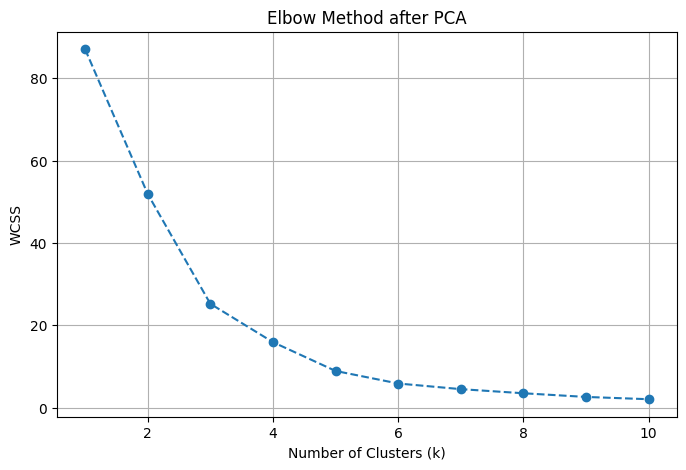

In [206]:
# Prepare numeric data
data_for_clustering = merged.select_dtypes(include=['float64', 'int64'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

# Apply PCA , keep enough components to explain 95% variance
pca = PCA(n_components=0.95)  # auto-selects components covering 95% variance
data_pca = pca.fit_transform(data_scaled)

print(f"PCA reduced from {data_scaled.shape[1]} to {data_pca.shape[1]} components.")
print("Explained variance ratio per component:", pca.explained_variance_ratio_)

# Elbow Method on PCA-reduced data
wcss = []
kmeans = None
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method after PCA')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [207]:
# Check feature contributions to each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=data_for_clustering.columns
)
print(loadings)

                              PC1       PC2       PC3
Military GDP % (2023)    0.714522  0.015816  0.699435
Armed_Forces_2020        0.580613 -0.571167 -0.580221
total_military_aid_2022  0.390317  0.820682 -0.417294


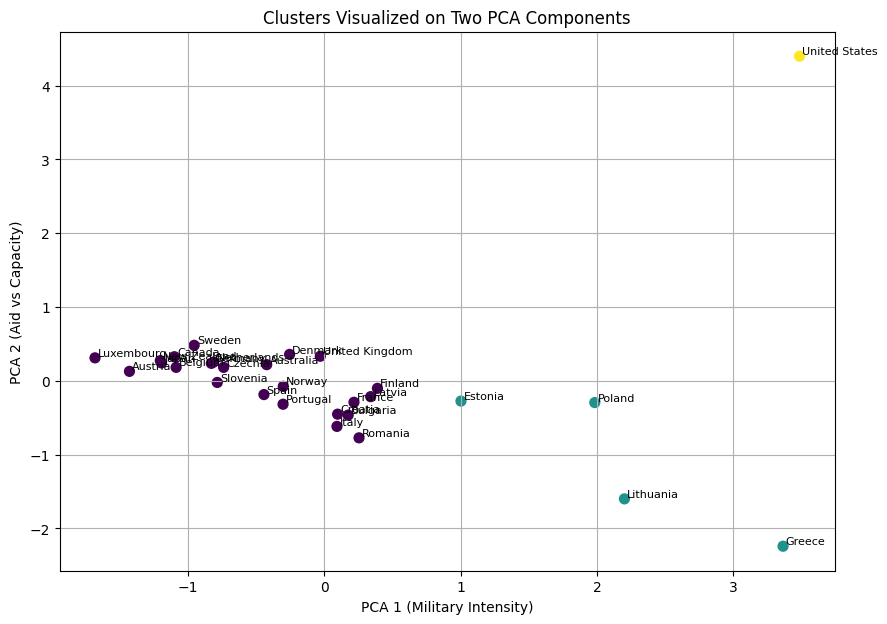

In [208]:
#rerun K-means for k=3
k=3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_pca)

# Plot PCA-reduced clusters
plt.figure(figsize=(10,7))
plt.scatter(data_pca[:,0], data_pca[:,1], c=clusters, cmap='viridis', s=50)

for i, country in enumerate(merged['Country Name']):
    plt.text(data_pca[i,0]+0.02, data_pca[i,1]+0.02, country, fontsize=8) # names each dot based on name

plt.title('Clusters Visualized on Two PCA Components')
plt.xlabel('PCA 1 (Military Intensity)')
plt.ylabel('PCA 2 (Aid vs Capacity)')
plt.grid(True)
plt.show()

In [211]:
#list out the clusters' countries and their PCA values

clusters = kmeans.fit_predict(data_pca) #returns labels of the clusters

# DataFrame for PCA component scores 
pca_scores = pd.DataFrame(
    data_pca[:, :2],  # first two components
    columns=['PCA1', 'PCA2']
)

# Combine everything with the original country names and cluster labels
merged_with_clusters = merged.copy()
merged_with_clusters['Cluster'] = clusters
merged_with_clusters = pd.concat([merged_with_clusters, pca_scores], axis=1)

# List countries in each cluster with PCA scores
for i in range(k):
    print(f"\n=== Cluster {i} ===")
    cluster_df = merged_with_clusters[merged_with_clusters['Cluster'] == i]
    print(cluster_df[['Country Name', 'PCA1', 'PCA2']].to_string(index=False))



=== Cluster 0 ===
  Country Name      PCA1      PCA2
       Austria -1.430952  0.128168
       Belgium -1.088521  0.182511
      Bulgaria  0.173708 -0.464541
        Canada -1.101255  0.326270
       Croatia  0.096261 -0.451880
       Denmark -0.256003  0.358122
       Czechia -0.740053  0.182090
       Finland  0.388331 -0.102122
        France  0.216156 -0.290911
       Germany -0.830142  0.236607
         Italy  0.091462 -0.617492
        Latvia  0.338742 -0.214700
    Luxembourg -1.683644  0.311065
      Portugal -0.304119 -0.317278
       Romania  0.253319 -0.772635
   Netherlands -0.812749  0.254358
        Norway -0.302520 -0.074862
      Slovenia -0.786444 -0.022209
         Spain -0.444200 -0.186439
        Sweden -0.956226  0.480767
United Kingdom -0.030881  0.333095
         Japan -1.195907  0.242505
   New Zealand -1.204533  0.273162
     Australia -0.423912  0.218681

=== Cluster 1 ===
Country Name     PCA1      PCA2
     Estonia 1.001236 -0.274763
      Greece 3.364088 -

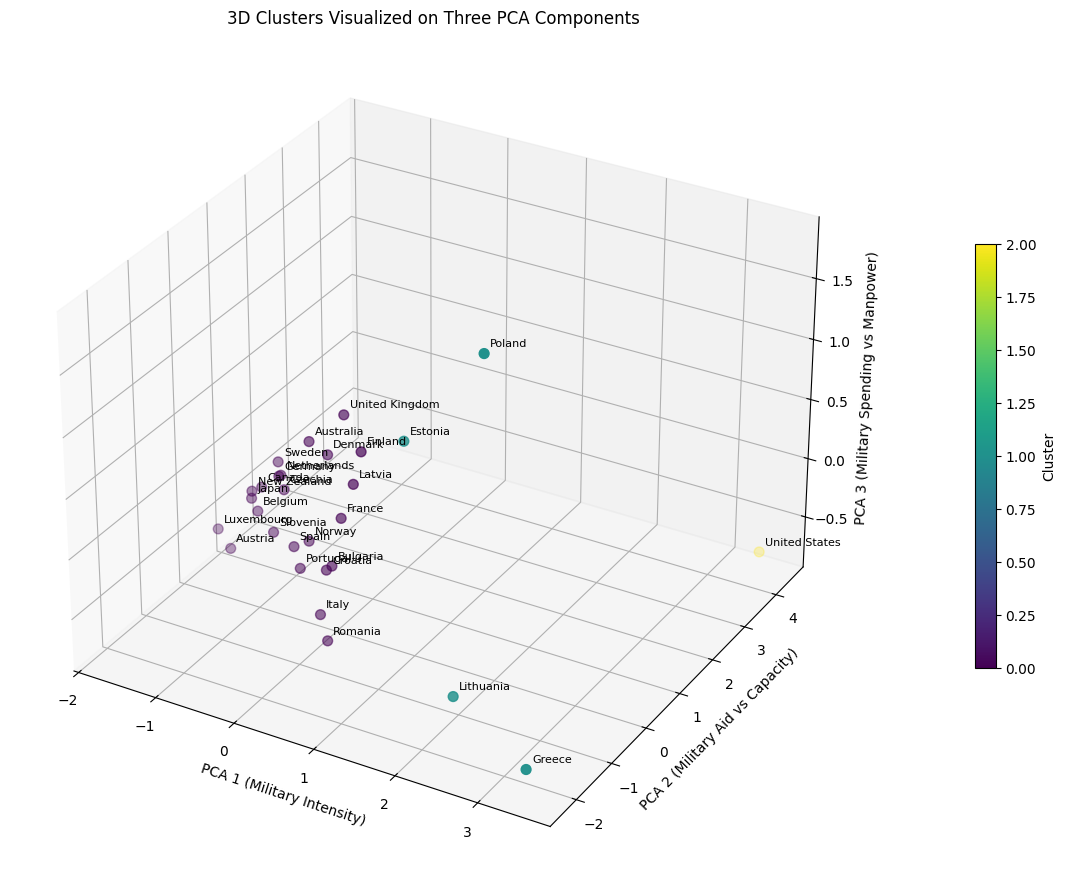

In [210]:

# Create 3D scatter plot
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

# Scatter the PCA data (3D)
scatter = ax.scatter(
    data_pca[:,0], data_pca[:,1], data_pca[:,2],
    c=clusters, cmap='viridis', s=50
)

# Label each point with country name
for i, country in enumerate(merged['Country Name']):
    ax.text(
        data_pca[i,0]+0.05, data_pca[i,1]+0.05, data_pca[i,2]+0.05,
        country, fontsize=8
    )


ax.set_xlabel('PCA 1 (Military Intensity)')
ax.set_ylabel('PCA 2 (Military Aid vs Capacity)')
ax.set_zlabel('PCA 3 (Military Spending vs Manpower)')


ax.set_title('3D Clusters Visualized on Three PCA Components')
plt.tight_layout()

plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1, label='Cluster') #color

plt.show()


In [197]:
# Build dataframe with PCA components and cluster labels
pca_scores = pd.DataFrame(
    data_pca[:, :3],
    columns=['PCA1', 'PCA2', 'PCA3']
)
pca_scores['Cluster'] = clusters
pca_scores['Country Name'] = merged['Country Name'].values

# Reorder columns 
pca_scores = pca_scores[['Country Name', 'Cluster', 'PCA1', 'PCA2', 'PCA3']]

# List countries per cluster
for i in sorted(pca_scores['Cluster'].unique()):
    print(f"\n=== Cluster {i} ===")
    cluster_df = pca_scores[pca_scores['Cluster'] == i]
    print(cluster_df[['Country Name', 'PCA1', 'PCA2', 'PCA3']].to_string(index=False))



=== Cluster 0 ===
  Country Name      PCA1      PCA2      PCA3
       Austria -1.430952  0.128168 -0.548779
       Belgium -1.088521  0.182511 -0.176172
      Bulgaria  0.173708 -0.464541 -0.214577
        Canada -1.101255  0.326270 -0.013247
       Croatia  0.096261 -0.451880 -0.267604
       Denmark -0.256003  0.358122  0.412581
       Czechia -0.740053  0.182090  0.072766
       Finland  0.388331 -0.102122  0.679804
        France  0.216156 -0.290911  0.146550
       Germany -0.830142  0.236607  0.154699
         Italy  0.091462 -0.617492 -0.599169
        Latvia  0.338742 -0.214700  0.432200
    Luxembourg -1.683644  0.311065 -0.480835
      Portugal -0.304119 -0.317278 -0.370839
       Romania  0.253319 -0.772635 -0.745157
   Netherlands -0.812749  0.254358  0.161757
        Norway -0.302520 -0.074862 -0.206031
      Slovenia -0.786444 -0.022209 -0.241679
         Spain -0.444200 -0.186439 -0.250792
        Sweden -0.956226  0.480767  0.187625
United Kingdom -0.030881  0.333095  